# Personal Information
### Full name: Kleanthis Vasileiadis
### sdi: 1115202200017   

# Libraries

In [1]:
#Libraries used for working with arrays
import numpy as np 
#Library used for reading the data
import pandas as pd
#Libraries used for data visualization and plotting
import matplotlib.pyplot as plt
pd.plotting.register_matplotlib_converters()
%matplotlib inline
import seaborn as sns
#Libraries used for data preprocessing
import re
import string
import emoji
import random
import nltk
import emoji
!pip install contractions 
import contractions
#Pytorch libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW
#Hugging face libraries
import transformers
from transformers import BertTokenizer, BertForSequenceClassification, BertModel
from transformers import get_scheduler
from transformers import set_seed
#Libraries used for evaluation
from sklearn.metrics import accuracy_score, roc_curve, auc, classification_report, confusion_matrix
#Setting random seed for reproducibility
def fixed_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

fixed_seed(42)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 289.9/289.9 kB 5.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.3/118.3 kB 8.2 MB/s eta 0:00:00


2025-05-11 11:42:02.286886: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746963722.528986      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746963722.605475      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Loading and reading the data

In [2]:
train_data = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv")
X_train_data = train_data["Text"]
y_train_data = train_data["Label"]
print(f"Training data")
print(train_data.head(5))
print(f"\n")

val_data = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv")
X_val_data = val_data["Text"]
y_val_data = val_data["Label"]
print(f"Validation data")
print(val_data.head(5))
print(f"\n")

test_data = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/test_dataset.csv")
X_test_data = test_data["Text"]
print(f"Testing data")
print(test_data.head(5))

Training data
       ID                                               Text  Label
0  189385      @whoisralphie dude  I'm so bummed ur leaving!      0
1   58036  oh my god, a severed foot was foun in a wheely...      0
2  190139  I end up &quot;dog dialing&quot; sumtimes. Wha...      1
3   99313                         @_rachelx meeeee toooooo!       0
4  157825  I was hoping I could stay home and work today,...      0


Validation data
       ID                                               Text  Label
0  187062  @NatexTheGreat heyheyhey maybe i will  get the...      0
1  168997  @molliesmummy Work? Work was crap. I missed yo...      0
2  194461  Want: Trip to Boston next month. Need: Addit'l...      1
3  165442                        first day starts tomorrow!       1
4   34853  @goodforyoursoul 8 course fish in Little Saigo...      1


Testing data
       ID                                               Text
0  102388  The books ARRIVED!!! Those who want a copy - w...
1  153802  @Spu

# Text Preprocessing

## Lists and dictionaries of tokens to be replaced

In [3]:
html_entities = {
            "&quot;": '"',         
            "&amp;": "and",         
            "&lt;": "less than",    
            "&gt;": "greater than"}

emoticons = {
        "<3": "love", 
        ":)": "happy", 
        ":-)": "happy", 
        ";)": "wink", 
        ":D": "laugh",
        ":(": "sad",
        ":o": "surprised",
        "XD": "laughing",
        "xD": "laughing",
        ":|": "neutral"}

slang_dict = {
    "u" : "you",
    "gr8" : "great",
    "fr" : "for real",
    "idk" : "i dont know",
    "btw" : "by the way",
    "thx" : "thanks",
    "thnx" : "thanks",
    "omg" : "oh my god"}

## Text preprocessing functions

In [4]:
#Replacing slang
def replace_slang(text):
    #Splitting words and puncuation
    tokens = re.findall(r'\w+|[^\w\s]', text)
    new_tokens = []
    for token in tokens:
        key = token.lower()
        if key in slang_dict:
            new_tokens.append(slang_dict[key])
        else:
            new_tokens.append(token)
    #join words and adding space only before a word and not a punctuation mark
    return ''.join([token if re.match(r'[^\w\s]', token) else ' ' + token for token in new_tokens]).strip()

#Replacing emoticons
def replace_emoticons(text):
    for emoticon, replacement in emoticons.items():
        text = text.replace(emoticon, replacement)
    return text

#Replacing html_entities
def replace_html_entities(text):
    for entity, char in html_entities.items():
        text = text.replace(entity, char)
    return text

def custom_preprocessor(text):
    #Replacing emojis
    text = emoji.demojize(text)
    #Replacing emoticons
    text = replace_emoticons(text)
    #Replacing HTML entities
    text = replace_html_entities(text) 
    #Replacing links
    text = re.sub(r"http[s]?://\S+|www\.\S+","link",text)
    #replacing slang
    text = replace_slang(text)
    #Fixing contractions
    text = contractions.fix(text)
    
    return text

## Applying text preprocessing

In [5]:
train_data["tokens"] = train_data["Text"].apply(custom_preprocessor)
print(f"\nCleaned training data")
print(train_data["tokens"].head(10))

val_data["tokens"] = val_data["Text"].apply(custom_preprocessor)
print(f"\nCleaned validation data")
print(val_data["tokens"].head(10))

test_data["tokens"] = test_data["Text"].apply(custom_preprocessor)
print(f"\nCleaned test data")
print(test_data["tokens"].head(10))


Cleaned training data
0    @ whoisralphie dude I' m so bummed you are lea...
1    oh my god, a severed foot was foun in a wheely...
2    I end up" dog dialing" sumtimes. What' s dog d...
3                           @ _rachelx meeeee toooooo!
4    I was hoping I could stay home and work today,...
5    says plurk karma finally reached the 50s. stil...
6    Good to hear it@ Arth This is a bit more, but ...
7    @ davorg in that case i am going to start twee...
8             @ belunyc its alright love, how are you?
9    @ brightondoll haha that has to be the best an...
Name: tokens, dtype: object

Cleaned validation data
0    @ NatexTheGreat heyheyhey maybe i will get the...
1    @ molliesmummy Work? Work was crap. I missed y...
2    Want: Trip to Boston next month. Need: Addit' ...
3                           first day starts tomorrow!
4    @ goodforyoursoul 8 course fish in Little Saig...
5    No milk for breakfast, grrr. But Looks like a ...
6    @ melremo I' m signed up to get news up

# Tokenization


## Loading BERT tokenizer

In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

## Tokenizing the datasets

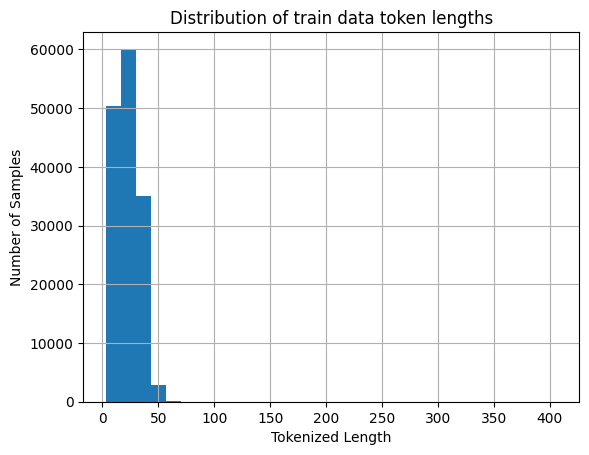

98 percent of train data has a length of: 44
Max length of train data: 406
98 percent of val data has a length of: 44
Max length of val data: 290
98 percent of test data has a length of: 43
Max length of test data: 341


In [7]:
#Function that finds the length of the biggest token and the length of the percentile given as argument
def find_best_max_len(texts, dataset, plot_histogram=False, percent=98):
    #Computing the length of each token
    token_lengths = [len(tokenizer.encode(text, add_special_tokens=True)) for text in texts]
    #Plotting the distribution
    if plot_histogram:
        pd.Series(token_lengths).hist(bins=30)
        plt.xlabel('Tokenized Length')
        plt.ylabel('Number of Samples')
        plt.title(f'Distribution of {dataset} token lengths')
        plt.show()
    #Computing the percentile and the max_length
    max_len = int(np.percentile(token_lengths, percent))
    real_max = max(token_lengths)
    print(f"{percent} percent of {dataset} has a length of: {max_len}")
    print(f"Max length of {dataset}: {real_max}")
    
    return max_len

#Function that tokenizes the datasets
def tokenize_data(train_data, val_data, test_data=None, plot_histogram=False):

    #Computing the best token max length
    max_train_len = find_best_max_len(train_data["tokens"].tolist(), "train data", plot_histogram)
    max_val_len = find_best_max_len(val_data["tokens"].tolist(), "val data")
    if test_data is not None:
        max_test_len = find_best_max_len(test_data["tokens"].tolist(), "test data")
    
    #Tokenizing the data and returning them as tensors
    train_encodings = tokenizer(list(train_data["tokens"]), padding="max_length", truncation=True,  max_length=max_train_len, return_tensors='pt')
    val_encodings = tokenizer(list(val_data["tokens"]), padding="max_length", truncation=True, max_length=max_val_len, return_tensors='pt')
    if test_data is not None:
        test_encodings = tokenizer(list(test_data["tokens"]), padding="max_length", truncation=True, max_length=max_test_len, return_tensors='pt')
    else:
        test_encodings = None
        
    #Transforming the labels into tensors
    train_labels_tensor = torch.tensor(train_data["Label"])
    val_labels_tensor = torch.tensor(val_data["Label"])

    return train_encodings, val_encodings, test_encodings, train_labels_tensor, val_labels_tensor

train_encodings, val_encodings, test_encodings, train_labels_tensor, val_labels_tensor = tokenize_data(train_data, val_data, test_data, 
                                                                                                                               plot_histogram=True)

## Creating the dataloaders

In [8]:
#Class that creates the Dataset
class TweetDataset(Dataset):
    #Initialization of the class
    def __init__(self, encodings, labels=None):
        self.encodings = encodings
        self.labels = labels
    #Returns the length
    def __len__(self):
        return len(next(iter(self.encodings.values())))
    #Returns a single item at the given index
    def __getitem__(self, idx):
         #Retrieves each input for index idx
        item = {key: val[idx] for key, val in self.encodings.items()}
         #If labels are provided, adds the label as well
        if self.labels is not None:
            item["labels"] = self.labels[idx]
        return item

#Creating the Datasets
train_dataset = TweetDataset(train_encodings, train_labels_tensor)
val_dataset = TweetDataset(val_encodings, val_labels_tensor)
test_dataset = TweetDataset(test_encodings)

#Creating the Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# BERT model

In [9]:
#Class that loads the BERT model
class CustomBERTClassifier(nn.Module):
    #Initilization function
    def __init__(self, dropout=0.1):
        super(CustomBERTClassifier, self).__init__()
        #Loading BERT base model
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        #Linear layer for classification
        self.classifier = nn.Linear(self.bert.config.hidden_size, 2)

    def forward(self, input_ids=None, attention_mask=None, inputs_embeds=None):
        #BERT's output
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, inputs_embeds=inputs_embeds)
        #Extracting the [CLS] token
        cls_token = outputs.last_hidden_state[:, 0]
        #linear classifier to the [CLS] token
        logits = self.classifier(cls_token)
        
        return logits

#Creating the model
model = CustomBERTClassifier()
print(model)

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

CustomBERTClassifier(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elem

# Training and evaluation

## Optimizer and loss function

In [10]:
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = nn.CrossEntropyLoss()

## Training and evaluation loop

In [11]:
#Running BERT on GPU(s) if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
    
def train_model(model, train_loader, val_loader, num_epochs, optimizer, criterion):
    
    #Adding a scheduler
    scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_epochs * len(train_loader),
    )

    #Loss and accuracy per epoch for both datasets
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

     #Predictions and labels for validation dataset
    all_labels = []
    all_preds = []
    
    #For each epoch
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        #Model in training
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        #For each batch in the training dataloader
        for i, batch in enumerate(train_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            #Delete previously stored gradients
            optimizer.zero_grad()
            #Models prediction
            logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            #Computing the loss
            loss = loss_fn(logits, batch["labels"])
            #Perform backpropagation starting from the loss calculated in this epoch
            loss.backward()
            #Clipping the gradients to prevent exploding gradients problem
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            #Update model's weights based on the gradients calculated during backprop
            optimizer.step()
            #Update the learning rate according to the scheduler
            scheduler.step()
            #Adding the loss to the total for the epoch
            train_loss += loss.item()
            #Computing the accuracy
            preds = torch.argmax(logits, dim=-1)
            train_correct += (preds == batch["labels"]).sum().item()
            train_total += batch["labels"].size(0)
            #Printing the batch loss every 100 batches
            if i % 100 == 0:
                print(f"Train batch: {i+1} | Loss: {loss.item():.4f}")
        #Saving the training results
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        train_losses.append(avg_train_loss)
        train_accuracies.append(train_acc)
        print(f"Train Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    
        #Validation on the validation dataset
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            #For each batch in the validation dataloader
            for i, batch in enumerate(val_loader):
                batch = {k: v.to(device) for k, v in batch.items()}
                #Models prediction
                logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
                #Computing the loss
                loss = loss_fn(logits, batch["labels"])
                #Adding the loss to the total for the epoch
                val_loss += loss.item()
                #Computing the accuracy
                preds = torch.argmax(logits, dim=-1)
                val_correct += (preds == batch["labels"]).sum().item()
                val_total += batch["labels"].size(0)
                #Collecting labels and softmax scores
                all_labels.extend(batch["labels"].detach().cpu().numpy())
                #Getting probability of positive class
                probs = torch.softmax(logits, dim=1)[:, 1]  
                all_preds.extend(probs.detach().cpu().numpy())
                #Printing the batch loss every 100 batches
                if i % 100 == 0:
                    print(f"Val batch: {i+1} | Loss: {loss.item():.4f}")
        #Saving the validation results
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)
        print(f"Val Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

    return train_losses, val_losses, train_accuracies, val_accuracies, all_preds, all_labels
        
train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model, train_loader, val_loader, 2, optimizer, loss_fn)


Epoch 1/2
Train batch: 1 | Loss: 0.7082
Train batch: 101 | Loss: 0.6574
Train batch: 201 | Loss: 0.3790
Train batch: 301 | Loss: 0.3845
Train batch: 401 | Loss: 0.4203
Train batch: 501 | Loss: 0.3356
Train batch: 601 | Loss: 0.2508
Train batch: 701 | Loss: 0.7179
Train batch: 801 | Loss: 0.2377
Train batch: 901 | Loss: 0.3761
Train batch: 1001 | Loss: 0.4158
Train batch: 1101 | Loss: 0.2250
Train batch: 1201 | Loss: 0.4348
Train batch: 1301 | Loss: 0.2269
Train batch: 1401 | Loss: 0.2175
Train batch: 1501 | Loss: 0.5161
Train batch: 1601 | Loss: 0.5014
Train batch: 1701 | Loss: 0.3889
Train batch: 1801 | Loss: 0.3234
Train batch: 1901 | Loss: 0.3061
Train batch: 2001 | Loss: 0.4645
Train batch: 2101 | Loss: 0.4291
Train batch: 2201 | Loss: 0.3671
Train batch: 2301 | Loss: 0.4435
Train batch: 2401 | Loss: 0.3295
Train batch: 2501 | Loss: 0.3506
Train batch: 2601 | Loss: 0.4541
Train batch: 2701 | Loss: 0.4076
Train batch: 2801 | Loss: 0.4021
Train batch: 2901 | Loss: 0.4096
Train batch

## Learning curve

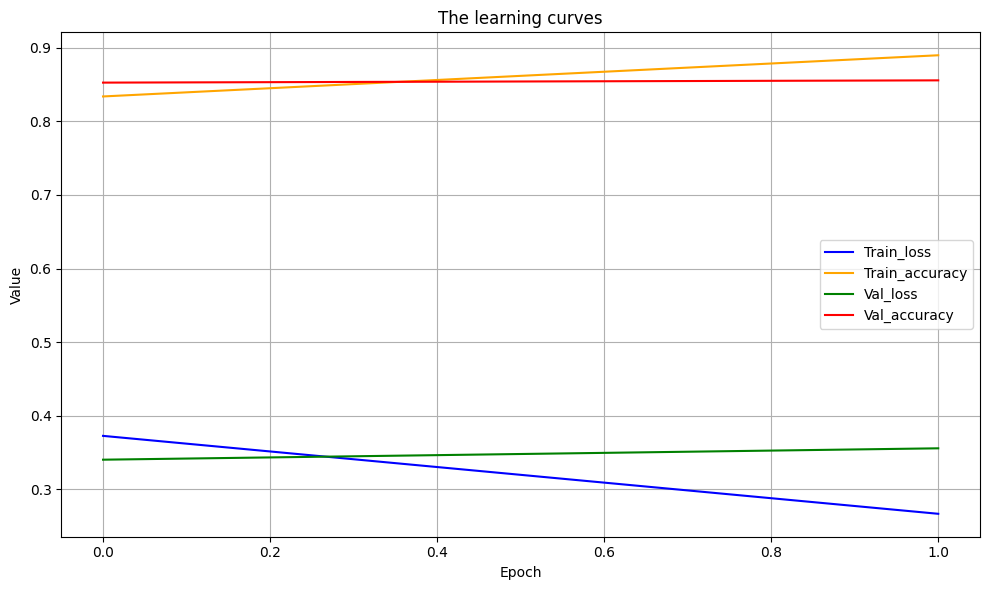

In [12]:
def learning_curve(train_losses, train_accuracies, val_losses, val_accuracies):
    #Creating the figure
    plt.figure(figsize=(10, 6))
    #Plotting the accuracies and losses
    plt.plot(train_losses, label='Train_loss', color='blue')
    plt.plot(train_accuracies, label='Train_accuracy', color='orange')
    plt.plot(val_losses, label='Val_loss', color='green')
    plt.plot(val_accuracies, label='Val_accuracy', color='red')
    #Creating the x and y labels
    plt.xlabel('Epoch')
    plt.ylabel('Value')
    plt.title('The learning curves')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    #Displaying the plot
    plt.show()

learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)

## ROC curve

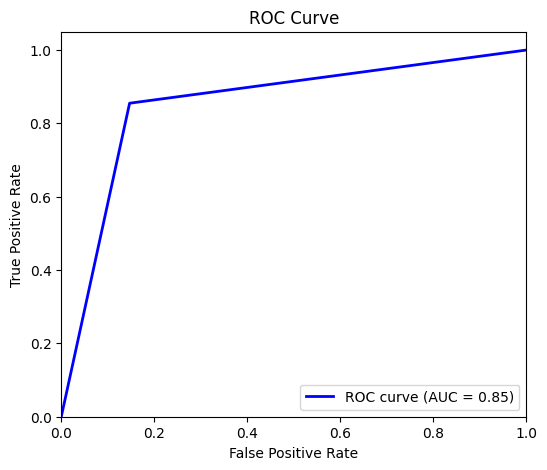

In [13]:
def ROC_curve(all_labels,all_preds):

    #Converting the labels to intergers
    all_labels = np.array(all_labels)
    all_labels = (all_labels >= 0.5).astype(int)
    #Computing the ROC curve
    fpr, tpr, thresholds = roc_curve(all_labels, all_preds)
    roc_auc = auc(fpr, tpr)
    
    #Plotting the ROC curve
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

ROC_curve(all_labels,all_preds)

## Classification Report and Confusion Matrix

              precision    recall  f1-score   support

           0       0.86      0.85      0.85     42510
           1       0.85      0.86      0.85     42282

    accuracy                           0.85     84792
   macro avg       0.85      0.85      0.85     84792
weighted avg       0.85      0.85      0.85     84792



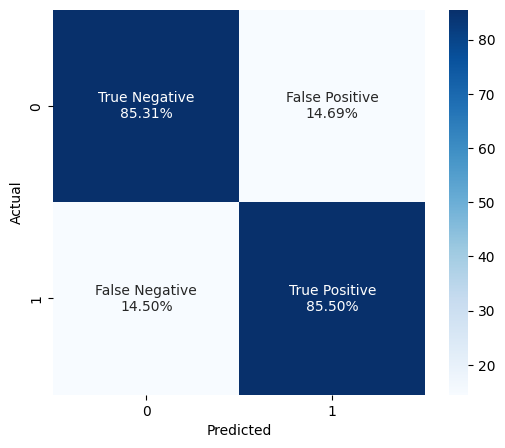

In [14]:
def cr_and_cm(all_labels,all_preds):

    #Converting the labels to intergers
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_labels = (np.array(all_labels) >= 0.5).astype(int)
    all_preds = (np.array(all_preds) >= 0.5).astype(int)
    
    #Printing the classification report
    print(classification_report(all_labels, all_preds))
    
    #Creating the confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    #Converting the values to percentages
    cm_percentage = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100  
    #Creating the lists
    labels = np.array([["True Negative", "False Positive"], ["False Negative", "True Positive"]])
    cm_labels = np.array([[f"{labels[i, j]}\n{cm_percentage[i, j]:.2f}%" for j in range(2)] for i in range(2)])
    
    #Plotting the confusion matrix
    plt.figure(figsize=(6,5))
    sns.heatmap(cm_percentage, annot=cm_labels, fmt="", cmap="Blues", xticklabels=['0', '1'], yticklabels=['0', '1'])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

cr_and_cm(all_labels,all_preds)

# Predictions on test set and submission to competition

In [15]:
#Validation on the testing dataset
model.eval()
all_preds = []
with torch.no_grad():
    #For each batch in the testing dataloader
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        #Models prediction
        logits = model(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        #Apends it to the predictions list
        preds = torch.argmax(logits, dim=-1)
        all_preds.extend(preds.cpu().numpy())
        
#Creating the predictions csv
submission = pd.DataFrame({"ID": test_data["ID"], "Label": all_preds})
submission.to_csv("submission.csv", index=False)

# Apendices

## Experiment 1: Baseline model

98 percent of train data has a length of: 46
Max length of train data: 259
98 percent of val data has a length of: 46
Max length of val data: 160

Epoch 1/1
Train batch: 1 | Loss: 0.6960
Train batch: 101 | Loss: 0.5076
Train batch: 201 | Loss: 0.4204
Train batch: 301 | Loss: 0.3289
Train batch: 401 | Loss: 0.3049
Train batch: 501 | Loss: 0.3773
Train batch: 601 | Loss: 0.5021
Train batch: 701 | Loss: 0.3067
Train batch: 801 | Loss: 0.5590
Train batch: 901 | Loss: 0.3070
Train batch: 1001 | Loss: 0.3583
Train batch: 1101 | Loss: 0.3581
Train batch: 1201 | Loss: 0.4337
Train batch: 1301 | Loss: 0.4767
Train batch: 1401 | Loss: 0.3732
Train batch: 1501 | Loss: 0.3549
Train batch: 1601 | Loss: 0.3313
Train batch: 1701 | Loss: 0.2905
Train batch: 1801 | Loss: 0.4425
Train batch: 1901 | Loss: 0.2614
Train batch: 2001 | Loss: 0.4892
Train batch: 2101 | Loss: 0.3868
Train batch: 2201 | Loss: 0.5182
Train batch: 2301 | Loss: 0.2706
Train batch: 2401 | Loss: 0.2759
Train batch: 2501 | Loss: 0.42

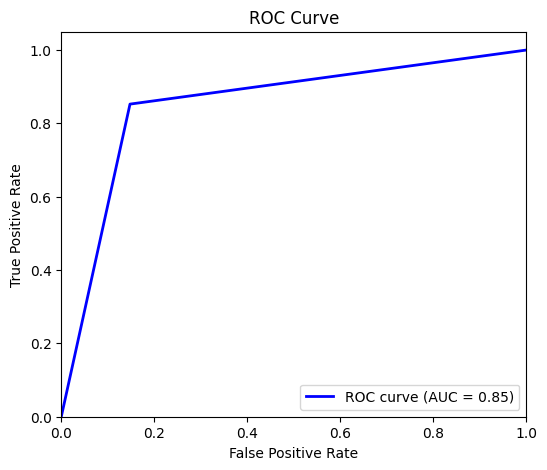

              precision    recall  f1-score   support

           0       0.85      0.85      0.85     21207
           1       0.85      0.85      0.85     21189

    accuracy                           0.85     42396
   macro avg       0.85      0.85      0.85     42396
weighted avg       0.85      0.85      0.85     42396



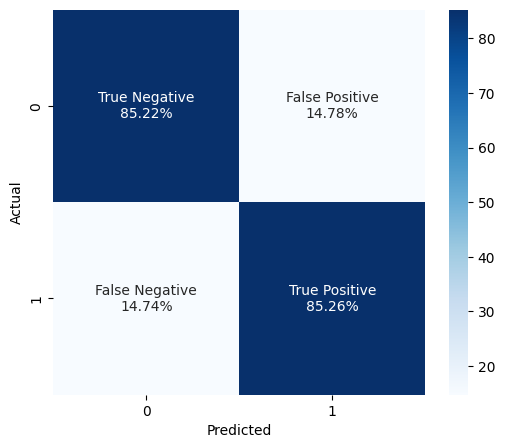

In [16]:
# #Reading the data
# train_data_E1 = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/train_dataset.csv")
# val_data_E1 = pd.read_csv("/kaggle/input/ai-2-dl-for-nlp-2025-homework-3/val_dataset.csv")
# train_data_E1["tokens"] = train_data_E1["Text"]
# val_data_E1["tokens"] = val_data_E1["Text"]

# #Tokenizing the datasets
# train_encodings1, val_encodings1, test_encodings1, train_labels_tensor1, val_labels_tensor1 = tokenize_data(train_data_E1, val_data_E1)

# #Creating the Datasets and Dataloaders
# train_dataset1 = TweetDataset(train_encodings1, train_labels_tensor1)
# train_loader1 = DataLoader(train_dataset1, batch_size=32, shuffle=True)
# val_dataset1 = TweetDataset(val_encodings1, val_labels_tensor1)
# val_loader1 = DataLoader(val_dataset1, batch_size=32, shuffle=False)

# #Creating the model
# model1 = CustomBERTClassifier()

# #Optimizer and Loss function
# optimizer1 = AdamW(model1.parameters(), lr=2e-5)
# loss_fn1 = nn.CrossEntropyLoss()

# #Running BERT on GPU(s) if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.cuda.device_count() > 1:
#     model1 = nn.DataParallel(model1)
# model1.to(device)

# #Training the model
# train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model1, train_loader1, val_loader1, 1, optimizer1, loss_fn1)

# #ROC curve
# ROC_curve(all_labels,all_preds)
# #Classification Report and Confusion Matrix
# cr_and_cm(all_labels,all_preds)

## Experiment 2: Number of epochs

98 percent of train data has a length of: 44
Max length of train data: 406
98 percent of val data has a length of: 44
Max length of val data: 290

Epoch 1/3
Train batch: 1 | Loss: 0.7043
Train batch: 101 | Loss: 0.5346
Train batch: 201 | Loss: 0.2792
Train batch: 301 | Loss: 0.4003
Train batch: 401 | Loss: 0.3570
Train batch: 501 | Loss: 0.3743
Train batch: 601 | Loss: 0.7015
Train batch: 701 | Loss: 0.3348
Train batch: 801 | Loss: 0.2975
Train batch: 901 | Loss: 0.2910
Train batch: 1001 | Loss: 0.3401
Train batch: 1101 | Loss: 0.6192
Train batch: 1201 | Loss: 0.3632
Train batch: 1301 | Loss: 0.3390
Train batch: 1401 | Loss: 0.4323
Train batch: 1501 | Loss: 0.2364
Train batch: 1601 | Loss: 0.2698
Train batch: 1701 | Loss: 0.2060
Train batch: 1801 | Loss: 0.2242
Train batch: 1901 | Loss: 0.3385
Train batch: 2001 | Loss: 0.4755
Train batch: 2101 | Loss: 0.3125
Train batch: 2201 | Loss: 0.4164
Train batch: 2301 | Loss: 0.3874
Train batch: 2401 | Loss: 0.3643
Train batch: 2501 | Loss: 0.23

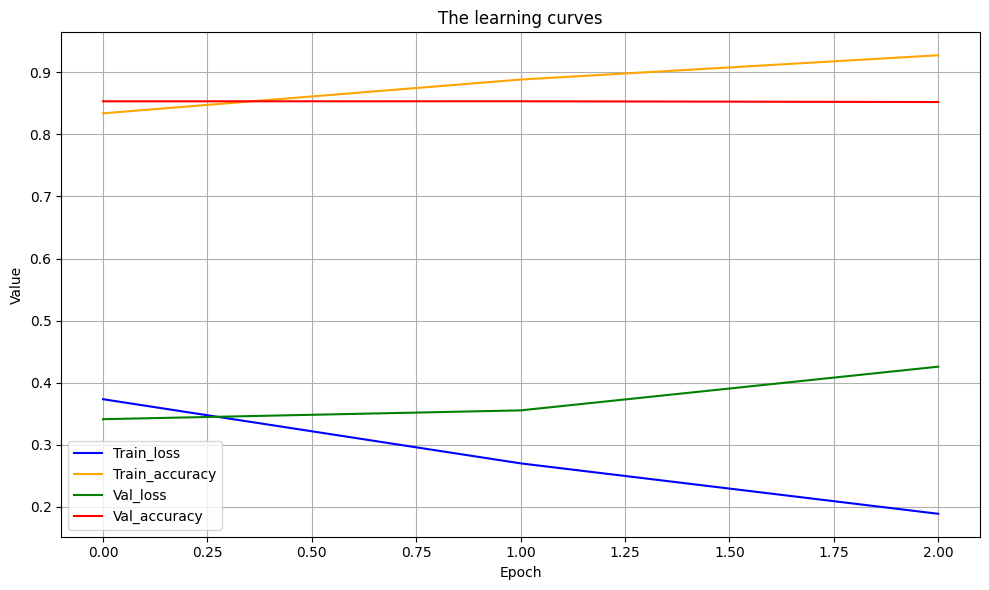

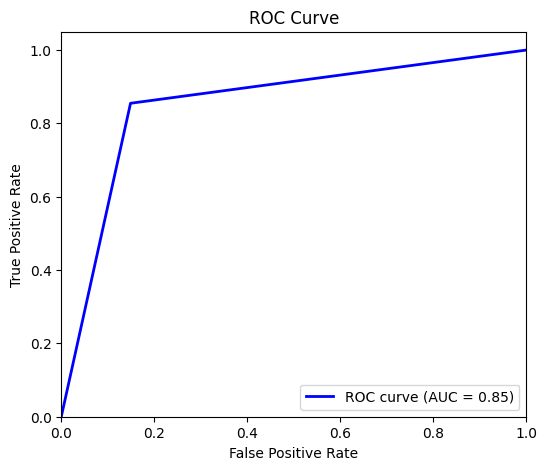

              precision    recall  f1-score   support

           0       0.86      0.85      0.85     63930
           1       0.85      0.85      0.85     63258

    accuracy                           0.85    127188
   macro avg       0.85      0.85      0.85    127188
weighted avg       0.85      0.85      0.85    127188



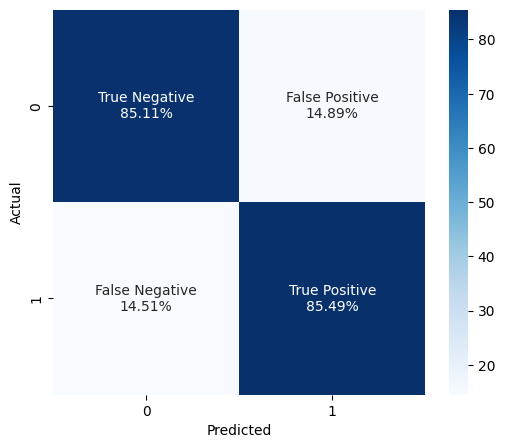

In [17]:
# train_data_E2 = train_data
# val_data_E2 = val_data

# #Tokenizing the datasets
# train_encodings2, val_encodings2, test_encodings2, train_labels_tensor2, val_labels_tensor2 = tokenize_data(train_data_E2, val_data_E2)

# #Creating the Datasets and Dataloaders
# train_dataset2 = TweetDataset(train_encodings2, train_labels_tensor2)
# train_loader2 = DataLoader(train_dataset, batch_size=32, shuffle=True)
# val_dataset2 = TweetDataset(val_encodings2, val_labels_tensor2)
# val_loader2 = DataLoader(val_dataset2, batch_size=32, shuffle=False)

# #Creating the model
# model2 = CustomBERTClassifier()

# #Optimizer and Loss function
# optimizer2 = AdamW(model2.parameters(), lr=2e-5)
# loss_fn2 = nn.CrossEntropyLoss()

# #Running BERT on GPU(s) if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.cuda.device_count() > 1:
#     model2 = nn.DataParallel(model2)
# model2.to(device)

# #Training the model
# train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model2, train_loader2, val_loader2, 3, optimizer2, loss_fn2)

# #Learning curve
# learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
# #ROC curve
# ROC_curve(all_labels,all_preds)
# #Classification Report and Confusion Matrix
# cr_and_cm(all_labels,all_preds)

## Experiment 3: Learning rate

98 percent of train data has a length of: 44
Max length of train data: 406
98 percent of val data has a length of: 44
Max length of val data: 290

Epoch 1/2
Train batch: 1 | Loss: 0.7136
Train batch: 101 | Loss: 0.5409
Train batch: 201 | Loss: 0.4418
Train batch: 301 | Loss: 0.6129
Train batch: 401 | Loss: 0.2611
Train batch: 501 | Loss: 0.4912
Train batch: 601 | Loss: 0.6374
Train batch: 701 | Loss: 0.3124
Train batch: 801 | Loss: 0.3505
Train batch: 901 | Loss: 0.3545
Train batch: 1001 | Loss: 0.3333
Train batch: 1101 | Loss: 0.4037
Train batch: 1201 | Loss: 0.5772
Train batch: 1301 | Loss: 0.3550
Train batch: 1401 | Loss: 0.3621
Train batch: 1501 | Loss: 0.3728
Train batch: 1601 | Loss: 0.4418
Train batch: 1701 | Loss: 0.5023
Train batch: 1801 | Loss: 0.1424
Train batch: 1901 | Loss: 0.4416
Train batch: 2001 | Loss: 0.2939
Train batch: 2101 | Loss: 0.5545
Train batch: 2201 | Loss: 0.2761
Train batch: 2301 | Loss: 0.2715
Train batch: 2401 | Loss: 0.4170
Train batch: 2501 | Loss: 0.25

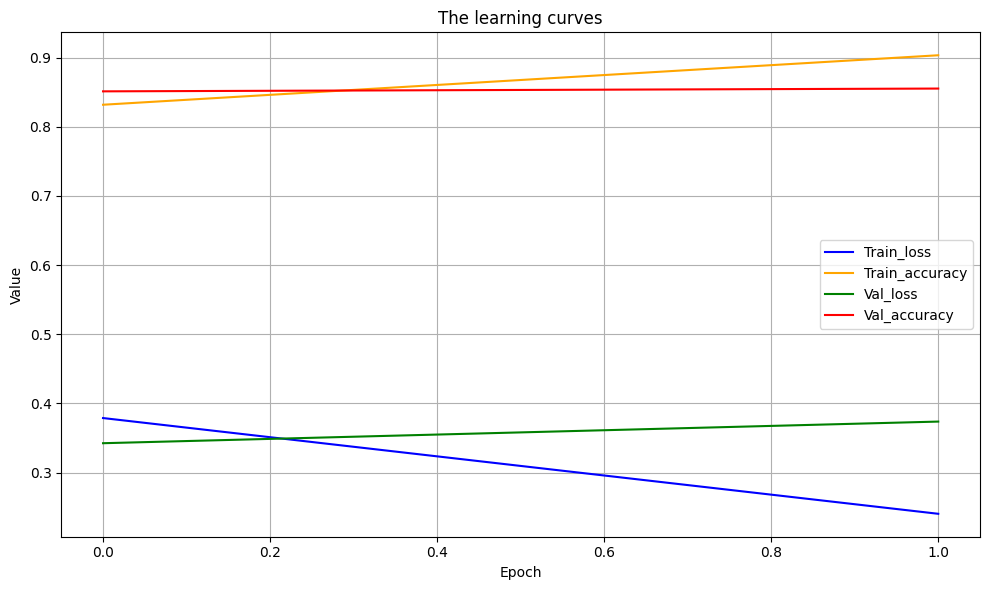

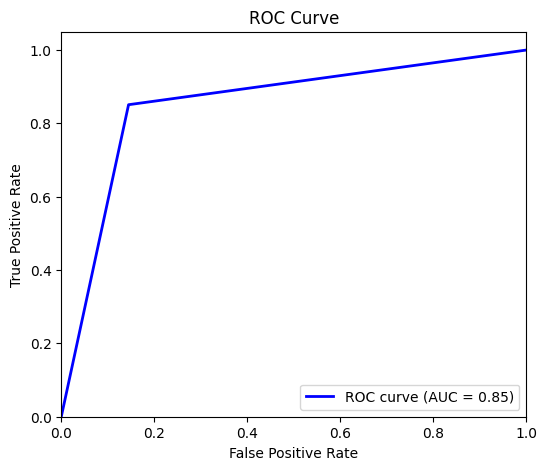

              precision    recall  f1-score   support

           0       0.85      0.86      0.85     42131
           1       0.86      0.85      0.85     42661

    accuracy                           0.85     84792
   macro avg       0.85      0.85      0.85     84792
weighted avg       0.85      0.85      0.85     84792



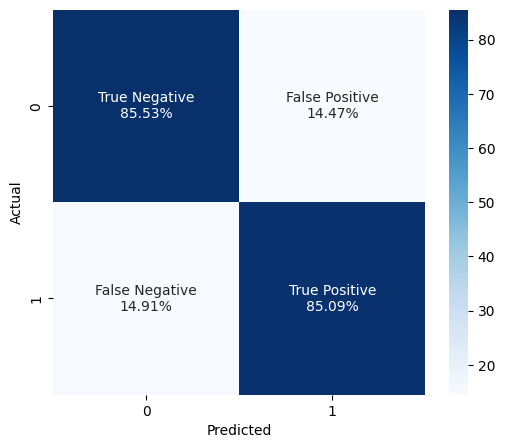

In [18]:
# train_data_E3 = train_data
# val_data_E3 = val_data

# #Tokenizing the datasets
# train_encodings3, val_encodings3, test_encodings3, train_labels_tensor3, val_labels_tensor3 = tokenize_data(train_data_E3, val_data_E3)

# #Creating the Datasets and Dataloaders
# train_dataset3 = TweetDataset(train_encodings3, train_labels_tensor3)
# train_loader3 = DataLoader(train_dataset3, batch_size=32, shuffle=True)
# val_dataset3 = TweetDataset(val_encodings3, val_labels_tensor3)
# val_loader3 = DataLoader(val_dataset3, batch_size=32, shuffle=False)

# #Creating the model
# model3 = CustomBERTClassifier()

# #Optimizer and Loss function
# optimizer3 = AdamW(model3.parameters(), lr=5e-5)
# loss_fn3 = nn.CrossEntropyLoss()

# #Running BERT on GPU(s) if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.cuda.device_count() > 1:
#     model3 = nn.DataParallel(model3)
# model3.to(device)

# #Training the model
# train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model3, train_loader3, val_loader3, 2, optimizer3, loss_fn3)

# #Learning curve
# learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
# #ROC curve
# ROC_curve(all_labels,all_preds)
# #Classification Report and Confusion Matrix
# cr_and_cm(all_labels,all_preds)

## Experiment 4: Batch size

98 percent of train data has a length of: 44
Max length of train data: 406
98 percent of val data has a length of: 44
Max length of val data: 290

Epoch 1/2
Train batch: 1 | Loss: 0.7962
Train batch: 101 | Loss: 0.3988
Train batch: 201 | Loss: 0.5163
Train batch: 301 | Loss: 0.3457
Train batch: 401 | Loss: 0.4168
Train batch: 501 | Loss: 0.4750
Train batch: 601 | Loss: 0.4425
Train batch: 701 | Loss: 0.2210
Train batch: 801 | Loss: 0.6212
Train batch: 901 | Loss: 0.4343
Train batch: 1001 | Loss: 0.4818
Train batch: 1101 | Loss: 0.6392
Train batch: 1201 | Loss: 0.4621
Train batch: 1301 | Loss: 0.3953
Train batch: 1401 | Loss: 0.4390
Train batch: 1501 | Loss: 0.2487
Train batch: 1601 | Loss: 0.5184
Train batch: 1701 | Loss: 0.3524
Train batch: 1801 | Loss: 0.6012
Train batch: 1901 | Loss: 0.2658
Train batch: 2001 | Loss: 0.3213
Train batch: 2101 | Loss: 0.7374
Train batch: 2201 | Loss: 0.3475
Train batch: 2301 | Loss: 0.2052
Train batch: 2401 | Loss: 0.2725
Train batch: 2501 | Loss: 0.41

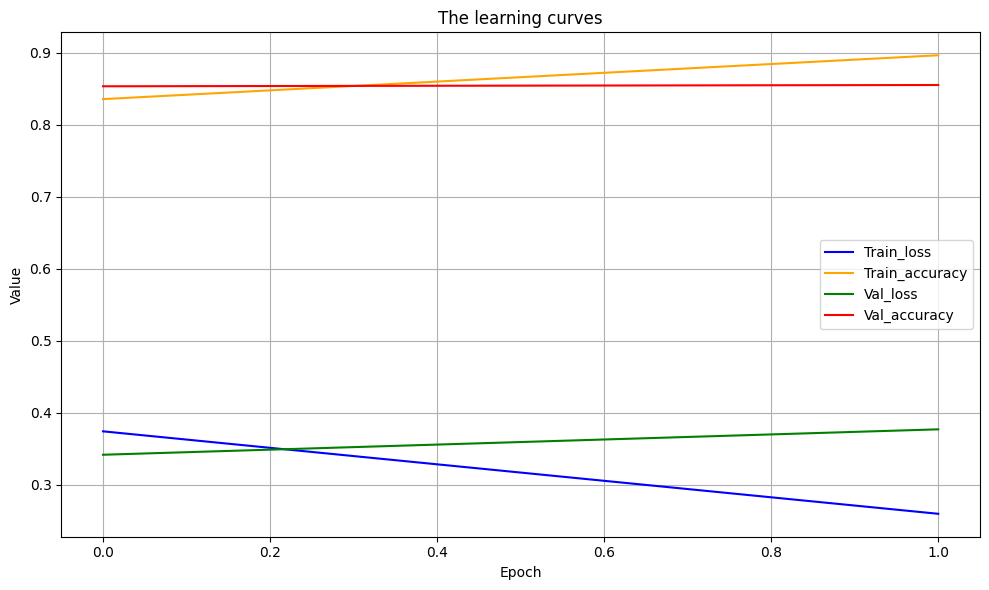

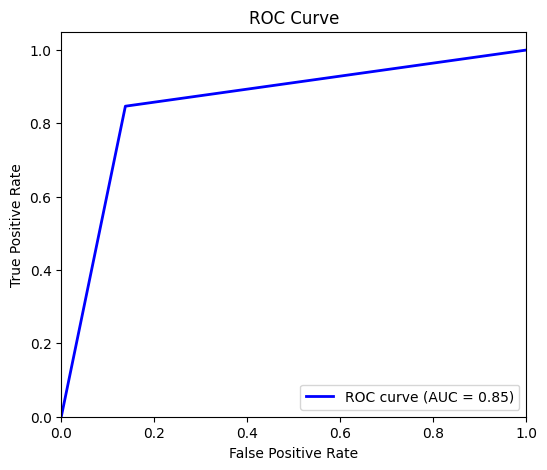

              precision    recall  f1-score   support

           0       0.84      0.86      0.85     41479
           1       0.87      0.85      0.86     43313

    accuracy                           0.85     84792
   macro avg       0.85      0.85      0.85     84792
weighted avg       0.85      0.85      0.85     84792



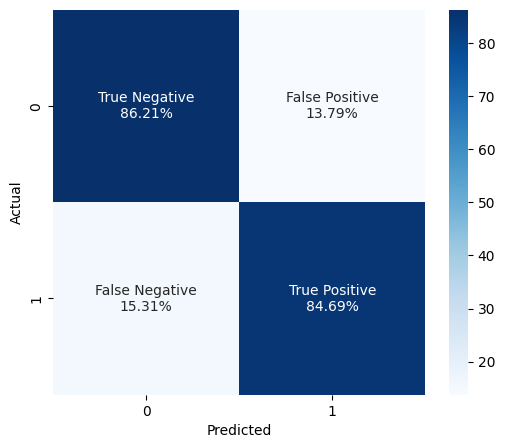

In [19]:
# train_data_E4 = train_data
# val_data_E4 = val_data

# #Tokenizing the datasets
# train_encodings4, val_encodings4, test_encodings4, train_labels_tensor4, val_labels_tensor4 = tokenize_data(train_data_E4, val_data_E4)

# #Creating the Datasets and Dataloaders
# train_dataset4 = TweetDataset(train_encodings4, train_labels_tensor4)
# train_loader4 = DataLoader(train_dataset4, batch_size=16, shuffle=True)
# val_dataset4 = TweetDataset(val_encodings4, val_labels_tensor4)
# val_loader4 = DataLoader(val_dataset4, batch_size=16, shuffle=False)

# #Creating the model
# model4 = CustomBERTClassifier()

# #Optimizer and Loss function
# optimizer4 = AdamW(model4.parameters(), lr=2e-5)
# loss_fn4 = nn.CrossEntropyLoss()

# #Running BERT on GPU(s) if available
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# if torch.cuda.device_count() > 1:
#     model4 = nn.DataParallel(model4)
# model4.to(device)

# #Training the model
# train_losses, val_losses, train_accuracies, val_accuracies, all_labels, all_preds = train_model(model4, train_loader4, val_loader4, 2, optimizer4, loss_fn4)

# #Learning curve
# learning_curve(train_losses, train_accuracies, val_losses, val_accuracies)
# #ROC curve
# ROC_curve(all_labels,all_preds)
# #Classification Report and Confusion Matrix
# cr_and_cm(all_labels,all_preds)